In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def order_points(pts):
    pts = pts.reshape(4, 2).astype("float32")
    ordered = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)            # x + y
    diff = pts[:, 1] - pts[:, 0]   # y - x

    ordered[0] = pts[np.argmin(s)]     # top-left    -> کمترین x+y
    ordered[3] = pts[np.argmax(s)]     # bottom-right-> بیشترین x+y
    ordered[1] = pts[np.argmin(diff)]  # top-right   -> کمترین y-x
    ordered[2] = pts[np.argmax(diff)]  # bottom-left -> بیشترین y-x

    return ordered


In [3]:
# -----------------------------------------------
# 2) find biggest and best countour and 4 points
# -----------------------------------------------
def find_paper_corners(binary_img, original_img, min_area_ratio=0.01):
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    all_contours = cv2.drawContours(original_img.copy(), contours, -1, (0, 255, 0), 2)
    approx_rect = original_img.copy()
    pts = None

    if len(contours) > 0:
        min_area = min_area_ratio * original_img.shape[0] * original_img.shape[1]
        valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

        if len(valid_contours) > 0:
            largest_contour = max(valid_contours, key=cv2.contourArea)
            peri = cv2.arcLength(largest_contour, True)
            approx = cv2.approxPolyDP(largest_contour, 0.04 * peri, True)

            if len(approx) == 4:
                cv2.drawContours(approx_rect, [approx], -1, (0, 255, 0), 5)
                pts = approx.reshape(4, 2)
            else:
                hull = cv2.convexHull(largest_contour)
                rect = cv2.minAreaRect(hull)
                box = cv2.boxPoints(rect)
                box = np.int32(box)
                pts = cv2.boxPoints(rect)
                cv2.drawContours(approx_rect, [box], -1, (0, 0, 255), 5)

    return pts, all_contours, approx_rect


In [4]:
# --------------------
# 3) Perspective Warp
# --------------------
def warp_paper(image, pts, out_size=(500, 700)):
    if pts is None:
        return None

    ordered_cords = order_points(pts)
    pts1 = np.float32(ordered_cords)
    w, h = out_size
    pts2 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
    M = cv2.getPerspectiveTransform(pts1, pts2)
    warped = cv2.warpPerspective(image, M, (w, h))
    return warped


In [5]:
# ------------------------------------------------------
# 4) preprocess for indoor photoes with normal light
# ------------------------------------------------------
def process_low_light(image, out_size=(500, 700)):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    kernel_ones = np.ones((5, 5), np.uint8)
    closing_remove_text = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel_ones, iterations=2)

    blur = cv2.GaussianBlur(closing_remove_text, (9, 9), 0)

    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1)

    abs_grad_x = cv2.convertScaleAbs(sobelx)
    abs_grad_y = cv2.convertScaleAbs(sobely)
    grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

    _, thresh = cv2.threshold(grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    dilation = cv2.dilate(thresh, kernel, iterations=1)

    pts, all_contours, approx_rect = find_paper_corners(dilation, image)
    warped = warp_paper(image, pts, out_size)

    return {
        "original": image,
        "thresh": thresh,
        "all_contours": all_contours,
        "approx_rect": approx_rect,
        "warped": warped,
    }


In [6]:
# ---------------------------------------------------
# 5) preprocess for outdoor photoes with high light
# ---------------------------------------------------
def process_high_light(image, out_size=(500, 700)):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    mean_l = int(np.mean(l))
    l_uniform = np.full_like(l, mean_l)

    lab_uniform = cv2.merge((l_uniform, a, b))
    result = cv2.cvtColor(lab_uniform, cv2.COLOR_LAB2RGB)
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    pts, all_contours, approx_rect = find_paper_corners(thresh, image)
    warped = warp_paper(image, pts, out_size)

    return {
        "l_channel": l,
        "uniform_result": result,
        "thresh": thresh,
        "approx_rect": approx_rect,
        "warped": warped,
    }

In [7]:
# ---------------------------------------------------
# 6) preprocess for white photos in white backgrund
# ---------------------------------------------------
def process_white_background(image, out_size=(500, 700)):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    l_channel = lab[:, :, 0]

    clahe = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(l_channel)

    bilateral = cv2.bilateralFilter(enhanced, 9, 75, 75)

    grad_x = cv2.Sobel(bilateral, cv2.CV_16S, 1, 0, ksize=1)
    grad_y = cv2.Sobel(bilateral, cv2.CV_16S, 0, 1, ksize=1)
    abs_grad_x = cv2.convertScaleAbs(grad_x)
    abs_grad_y = cv2.convertScaleAbs(grad_y)
    grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

    _, thresh = cv2.threshold(grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel_huge = cv2.getStructuringElement(cv2.MORPH_RECT, (41, 41))
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel_huge, iterations=5)

    pts, all_contours, approx_rect = find_paper_corners(closing, image)
    warped = warp_paper(image, pts, out_size)

    return {
        "image_rgb": image_rgb,
        "l_channel": l_channel,
        "enhanced": enhanced,
        "bilateral": bilateral,
        "grad": grad,
        "thresh": thresh,
        "closing": closing,
        "warped": warped,
    }

In [8]:
# -----------------------------
# 7) auto detect image type
# -----------------------------
def classify_image(img, verbose=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_val = np.mean(gray)
    std_val = np.std(gray)
    bright_ratio = np.sum(gray > 220) / gray.size

    edges = cv2.Canny(gray, 50, 150)
    edge_ratio = np.sum(edges > 0) / edges.size

    if std_val < 30 and edge_ratio < 0.03:
        mode = "white_on_white"
    elif edge_ratio > 0.085 and mean_val > 130 and std_val < 65:
        mode = "bright_outdoor"
    else:
        mode = "normal_indoor"

    if verbose:
        print(f"Mean: {mean_val:.2f}")
        print(f"Std: {std_val:.2f}")
        print(f"Bright Ratio: {bright_ratio:.4f}")
        print(f"Edge Ratio: {edge_ratio:.4f}")
        print("Detected mode:", mode)

    return mode


def detect_paper(img, verbose=True):
    return classify_image(img, verbose=verbose)


MODE_TO_PROCESSOR = {
    "white_on_white": process_white_background,
    "bright_outdoor": process_high_light,
    "normal_indoor": process_low_light,
}


def auto_process(image, out_size=(500, 700), verbose=False):
    mode = classify_image(image, verbose=verbose)
    processor = MODE_TO_PROCESSOR[mode]
    results = processor(image, out_size=out_size)
    return mode, results


In [9]:
# ----------------------------------
# 8) light correction and sharpening
# ----------------------------------
def correct_light_and_sharpness(image):
    channels = cv2.split(image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    equalized_channels = [clahe.apply(ch) for ch in channels]
    equalized_image = cv2.merge(equalized_channels)

    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])
    sharpened_equalized_image = cv2.filter2D(equalized_image, -1, kernel)

    return equalized_image, sharpened_equalized_image


In [10]:
def remove_shadows(warped):
    img = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))

    background = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    result = cv2.divide(img, background, scale=255)

    result = cv2.adaptiveThreshold(result,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 10 )

    return result

In [11]:
# -----------------------------------------
# 9) correct image orientation (optional)
# -----------------------------------------
def fix_orientation(warped):
    if warped is None:
        return warped

    h, w = warped.shape[:2]
    if h > w:
        warped = cv2.rotate(warped, cv2.ROTATE_90_COUNTERCLOCKWISE)
        warped = cv2.resize(warped, (w, h))
    return warped


In [12]:
def plot_results(images, titles=None, figsize=(12, 10), gray_titles=None, cols=4):
    if isinstance(images, dict):
        titles = list(images.keys())
        images = list(images.values())
    elif titles is None:
        titles = [f"image_{i}" for i in range(len(images))]

    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(rows, cols, i)

        if img is None:
            plt.text(0.5, 0.5, "None", ha="center", va="center")

        elif isinstance(img, str):
            plt.text(0.5, 0.5, img, ha="center", va="center")
        
        elif isinstance(img, dict):
            plt.text(0.5, 0.5, f"dict: {title}", ha="center", va="center")

        elif isinstance(img, np.ndarray):
            if img.ndim == 2 or (gray_titles and title in gray_titles):
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img[..., ::-1])

        else:
            plt.text(0.5, 0.5, str(type(img)), ha="center", va="center")

        plt.title(title)
        plt.axis("off")

    plt.show()


In [13]:
def auto_process_with_full_pipeline(image, out_size=(500, 700), verbose=True):
    mode = classify_image(image, verbose=verbose)
    print("Detected Mode:", mode)

    processor = MODE_TO_PROCESSOR[mode]
    results = processor(image, out_size=out_size)

    warped = results.get("warped", None)

    if warped is not None:
        shadow_removed = remove_shadows(warped)
        shadow_bgr = cv2.cvtColor(shadow_removed, cv2.COLOR_GRAY2BGR)
        eq, sharp = correct_light_and_sharpness(shadow_bgr)
    else:
        shadow_removed, eq, sharp = None, None, None

    return {
        "mode": mode,
        "raw_results": results,
        "shadow_removed": shadow_removed,
        "equalized": eq,
        "sharpened": sharp,
    }


Mean: 153.48
Std: 59.86
Bright Ratio: 0.0844
Edge Ratio: 0.1219
Detected mode: bright_outdoor
Detected Mode: bright_outdoor


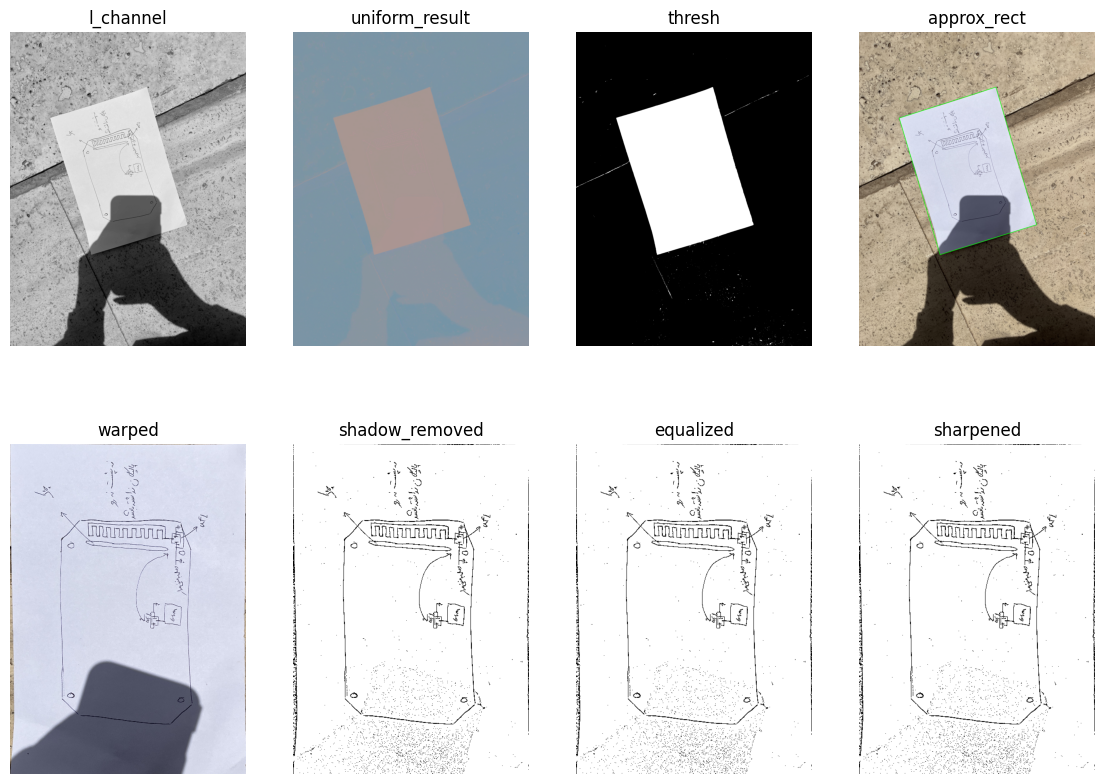

In [14]:
img = cv2.imread("../papers/paper11.jpg")
out = auto_process_with_full_pipeline(img, verbose=True)

display_dict = {
    **out["raw_results"],
    "shadow_removed": out["shadow_removed"],
    "equalized": out["equalized"],
    "sharpened": out["sharpened"],
}

plot_results(
    display_dict,
    figsize=(14, 10),
    gray_titles=["thresh", "closing", "grad", "l_channel", "enhanced", "bilateral", "shadow_removed"]
)


Mean: 159.41
Std: 48.72
Bright Ratio: 0.1485
Edge Ratio: 0.0327
Detected mode: normal_indoor
Detected Mode: normal_indoor


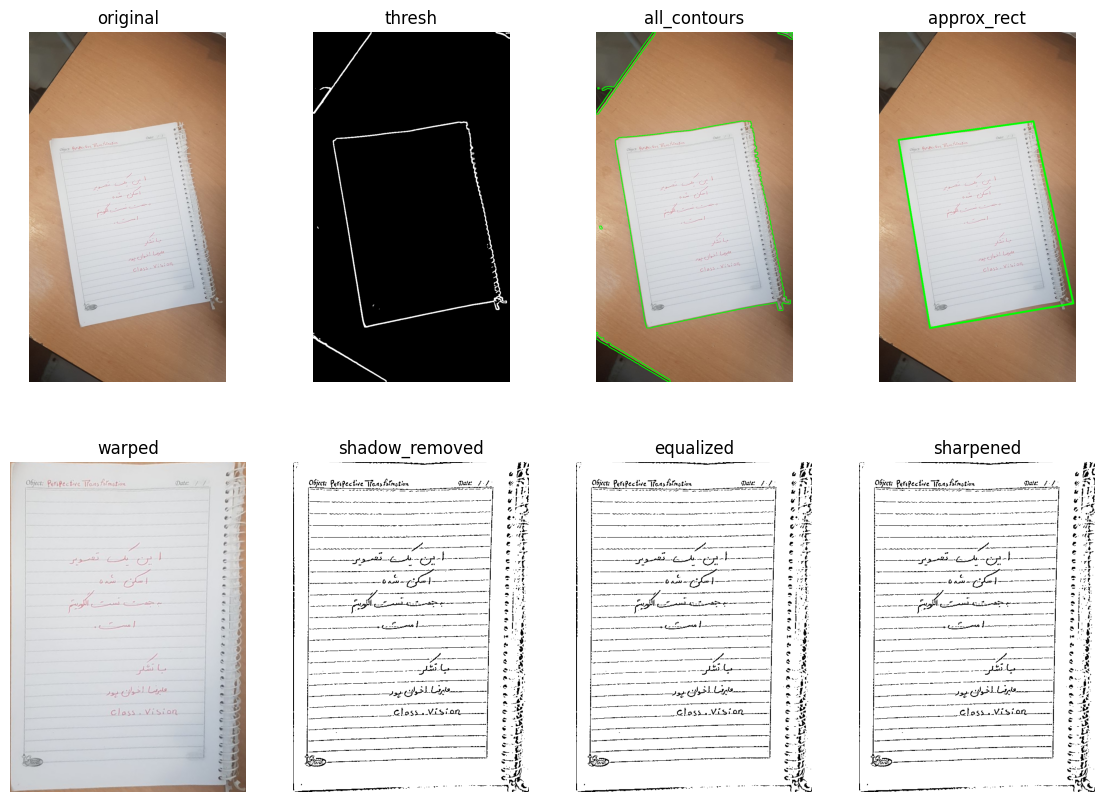

In [15]:
img = cv2.imread("../papers/paper1.jpg")
out = auto_process_with_full_pipeline(img, verbose=True)

display_dict = {
    **out["raw_results"],
    "shadow_removed": out["shadow_removed"],
    "equalized": out["equalized"],
    "sharpened": out["sharpened"],
}

plot_results(
    display_dict,
    figsize=(14, 10),
    gray_titles=["thresh", "closing", "grad", "l_channel", "enhanced", "bilateral", "shadow_removed"]
)


Mean: 169.38
Std: 20.46
Bright Ratio: 0.0046
Edge Ratio: 0.0191
Detected mode: white_on_white
Detected Mode: white_on_white


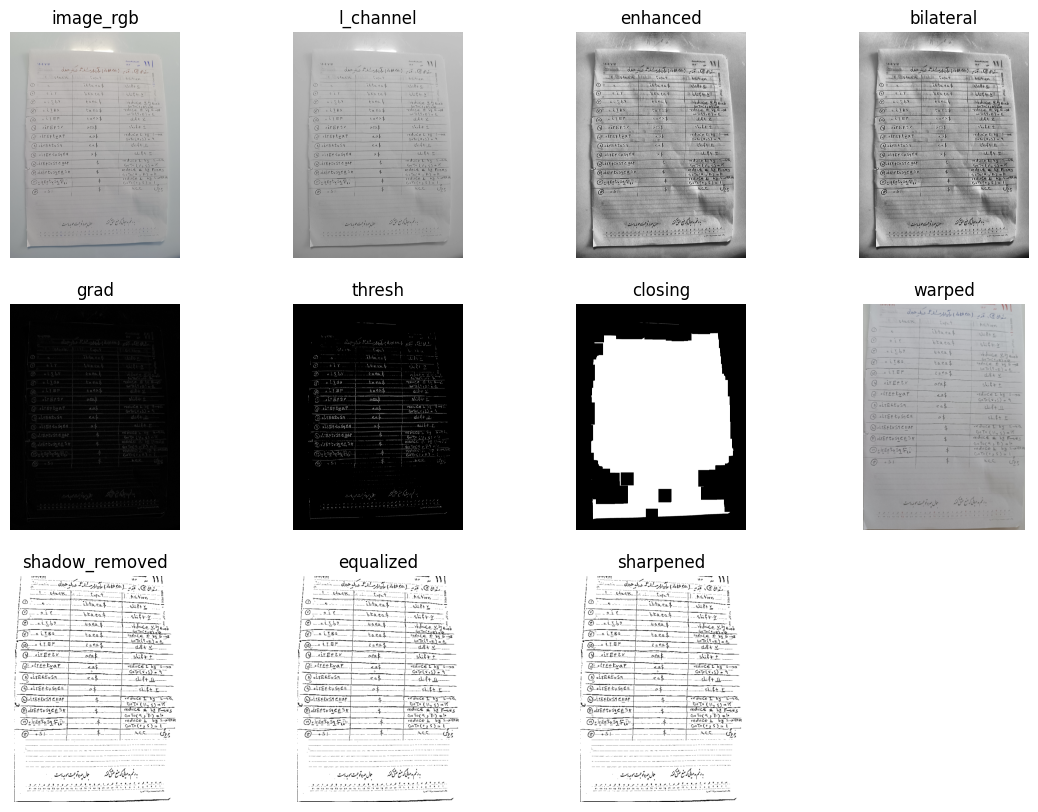

In [16]:
img = cv2.imread("../papers/paper6.jpg")
out = auto_process_with_full_pipeline(img, verbose=True)

display_dict = {
    **out["raw_results"],
    "shadow_removed": out["shadow_removed"],
    "equalized": out["equalized"],
    "sharpened": out["sharpened"],
}

plot_results(
    display_dict,
    figsize=(14, 10),
    gray_titles=["thresh", "closing", "grad", "l_channel", "enhanced", "bilateral", "shadow_removed"]
)
